# Semantic Search with Transformer Embeddings and FAISS

This notebook builds a **semantic-search engine** with `sentence-transformers/all-MiniLM-L6-v2` and **FAISS**. It also evaluates how fast the embedding step runs on **CPU** and on an **NVIDIA GPU (PyTorch CUDA)**.

**Experiments**
1. CPU vs GPU embedding generation for 1,000 / 5,000 / 10,000 documents
2. GPU batch-size comparison (16, 32, 64, 128)
3. GPU memory and throughput analysis
4. Semantic-search demonstration with example queries
5. A check that CPU and GPU embeddings are numerically equivalent

In [ ]:
!pip install -q sentence-transformers faiss-cpu datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 56.1 MB/s eta 0:00:00


In [2]:
import os, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss
from sentence_transformers import SentenceTransformer
from datasets import load_dataset

MODEL_NAME  = "sentence-transformers/all-MiniLM-L6-v2"
SIZES       = [1_000, 5_000, 10_000]   # dataset subsets
BATCH_SIZES = [16, 32, 64, 128]        # GPU batch-size experiment
DEFAULT_BS  = 64                       # batch size for CPU-vs-GPU comparison
REPEATS     = 3                        # timed runs per configuration
SEED        = 42

for d in ["data", "results", "plots"]:
    os.makedirs(d, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
assert torch.cuda.is_available(), "No GPU found - switch the Colab runtime to GPU and re-run."

env = {
    "gpu_name":        torch.cuda.get_device_name(0),
    "gpu_total_mem_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    "cuda_version":    torch.version.cuda,
    "torch_version":   torch.__version__,
    "cpu":             platform.processor() or platform.machine(),
    "cpu_threads":     torch.get_num_threads(),
    "python":          platform.python_version(),
}
for k, v in env.items():
    print(f"{k:18s}: {v}")
pd.Series(env).to_csv("results/environment.csv", header=["value"])

gpu_name          : Tesla T4
gpu_total_mem_gb  : 14.56
cuda_version      : 13.0
torch_version     : 2.11.0+cu130
cpu               : x86_64
cpu_threads       : 1
python            : 3.13.15


In [4]:
!nvidia-smi | tail -n +2

+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+------------

The notebook uses **AG News**, a public dataset of news-article snippets labeled World / Sports / Business / Sci-Tech.
It takes 12,000 unique passages and saves them to `data/documents.csv`.
The subject of the text doesn't matter much here because the project measures embedding performance.

The subsets are **nested**: the 1k subset is the first 1,000 rows of the 5k subset, and so on.

In [6]:
ds = load_dataset("fancyzhx/ag_news", split="train")
df = ds.to_pandas().drop_duplicates("text").sample(n=12_000, random_state=SEED).reset_index(drop=True)
label_names = ds.features["label"].names
df["category"] = df["label"].map(lambda i: label_names[i])
df = df[["text", "category"]]
df.to_csv("data/documents.csv", index_label="doc_id")

all_texts = df["text"].tolist()
subsets = {n: all_texts[:n] for n in SIZES}

print(f"{len(df):,} documents saved to data/documents.csv")
print("Average length (words):", round(df['text'].str.split().str.len().mean(), 1))
df.head()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

12,000 documents saved to data/documents.csv
Average length (words): 37.8


,text,category
0,"BBC set for major shake-up, claims newspaper L...",Business
1,Marsh averts cash crunch Embattled insurance b...,Business
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",Sports
3,Flying the Sun to Safety When the Genesis caps...,Sci/Tech
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,Business


Methodology for every configuration:

```
warm-up encode (not timed)
repeat 3x:
    synchronize -> start timer -> encode -> synchronize -> stop timer
report mean (and std) time, throughput = docs / mean time, peak GPU memory
```

**Why `torch.cuda.synchronize()`?** CUDA kernels launch *asynchronously*, so Python can carry on before the GPU has finished its work.
Synchronizing before starting the timer means earlier GPU work is not counted. Synchronizing before stopping it means all of the timed work is complete.

**Why warm up?** The first CUDA call pays one-time costs such as context creation, cuBLAS/cuDNN initialization, kernel selection and memory-allocator growth.
These costs are not part of steady-state inference speed.

In [7]:
def sync(device):
    if device == "cuda":
        torch.cuda.synchronize()

def benchmark(model, texts, batch_size, device, repeats=REPEATS):
    # Warm-up (not timed)
    model.encode(texts[:100], batch_size=min(batch_size, 32), show_progress_bar=False)
    sync(device)

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    times = []
    for _ in range(repeats):
        sync(device)
        start = time.perf_counter()
        emb = model.encode(texts, batch_size=batch_size, show_progress_bar=False)
        sync(device)
        times.append(time.perf_counter() - start)

    mean_t = float(np.mean(times))
    result = {
        "device": device,
        "n_docs": len(texts),
        "batch_size": batch_size,
        "times_s": [round(t, 4) for t in times],
        "mean_time_s": mean_t,
        "std_time_s": float(np.std(times)),
        "throughput_docs_per_s": len(texts) / mean_t,
    }
    if device == "cuda":
        result["peak_mem_allocated_mb"] = torch.cuda.max_memory_allocated() / 1024**2
        result["peak_mem_reserved_mb"]  = torch.cuda.max_memory_reserved() / 1024**2
    return result, emb

###  Experiment 1a: CPU baseline

The model is placed explicitly on the CPU. On Colab's small CPU, the 10k run can take a few minutes because each configuration runs 3 times.

In [8]:
cpu_model = SentenceTransformer(MODEL_NAME, device="cpu")
print("Model device:", cpu_model.device, "| embedding dim:", cpu_model.get_sentence_embedding_dimension())

cpu_results, cpu_embeddings = [], {}
for n in SIZES:
    res, emb = benchmark(cpu_model, subsets[n], DEFAULT_BS, "cpu")
    cpu_results.append(res)
    cpu_embeddings[n] = emb
    print(f"CPU | {n:>6,} docs | {res['mean_time_s']:8.2f} s ± {res['std_time_s']:.2f} | "
          f"{res['throughput_docs_per_s']:8.1f} docs/s")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_3170/3492128838.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Model device:", cpu_model.device, "| embedding dim:", cpu_model.get_sentence_embedding_dimension())


Model device: cpu | embedding dim: 384
CPU |  1,000 docs |    27.13 s ± 6.49 |     36.9 docs/s
CPU |  5,000 docs |   111.91 s ± 10.85 |     44.7 docs/s
CPU | 10,000 docs |   200.92 s ± 4.27 |     49.8 docs/s


### Experiment 1b: GPU (CUDA)

The workload is the same as the CPU baseline: the same texts, batch size 64 and 3 repeats. The only difference is `device="cuda"`.

In [9]:
gpu_model = SentenceTransformer(MODEL_NAME, device="cuda")
print("Model device:", gpu_model.device)
print(f"GPU memory after loading model: {torch.cuda.memory_allocated() / 1024**2:.1f} MB allocated")

gpu_results, gpu_embeddings = [], {}
for n in SIZES:
    res, emb = benchmark(gpu_model, subsets[n], DEFAULT_BS, "cuda")
    gpu_results.append(res)
    gpu_embeddings[n] = emb
    print(f"GPU | {n:>6,} docs | {res['mean_time_s']:8.3f} s ± {res['std_time_s']:.3f} | "
          f"{res['throughput_docs_per_s']:8.1f} docs/s | peak mem {res['peak_mem_allocated_mb']:.0f} MB")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model device: cuda:0
GPU memory after loading model: 86.7 MB allocated
GPU |  1,000 docs |    0.781 s ± 0.029 |   1280.3 docs/s | peak mem 365 MB
GPU |  5,000 docs |    3.675 s ± 0.136 |   1360.4 docs/s | peak mem 365 MB
GPU | 10,000 docs |    7.353 s ± 0.241 |   1360.0 docs/s | peak mem 365 MB


### CPU vs GPU comparison: time, throughput and speedup

In [10]:
cpu_df = pd.DataFrame(cpu_results).set_index("n_docs")
gpu_df = pd.DataFrame(gpu_results).set_index("n_docs")

comparison = pd.DataFrame({
    "CPU time (s)":             cpu_df["mean_time_s"],
    "GPU time (s)":             gpu_df["mean_time_s"],
    "CPU throughput (docs/s)":  cpu_df["throughput_docs_per_s"],
    "GPU throughput (docs/s)":  gpu_df["throughput_docs_per_s"],
    "Speedup (CPU/GPU)":        cpu_df["mean_time_s"] / gpu_df["mean_time_s"],
    "GPU peak mem (MB)":        gpu_df["peak_mem_allocated_mb"],
})
comparison.index.name = "Documents"
comparison.to_csv("results/cpu_vs_gpu.csv")
comparison.round(2)

,CPU time (s),GPU time (s),CPU throughput (docs/s),GPU throughput (docs/s),Speedup (CPU/GPU),GPU peak mem (MB)
Documents,,,,,,
1000,27.13,0.78,36.87,1280.29,34.73,364.78
5000,111.91,3.68,44.68,1360.40,30.45,364.78
10000,200.92,7.35,49.77,1360.03,27.33,364.78


### Experiment 2: GPU batch-size comparison

This experiment runs the 10,000-document set on the GPU with batch sizes 16, 32, 64 and 128.
Larger batches give the GPU more parallel work per kernel launch. The cost is more activation memory.

In [11]:
batch_results = []
texts_10k = subsets[10_000]
for bs in BATCH_SIZES:
    torch.cuda.empty_cache()
    res, _ = benchmark(gpu_model, texts_10k, bs, "cuda")
    batch_results.append(res)
    print(f"batch {bs:>4} | {res['mean_time_s']:7.3f} s | {res['throughput_docs_per_s']:8.1f} docs/s | "
          f"peak allocated {res['peak_mem_allocated_mb']:7.1f} MB | reserved {res['peak_mem_reserved_mb']:7.1f} MB")

batch_df = pd.DataFrame(batch_results)[
    ["batch_size", "mean_time_s", "std_time_s", "throughput_docs_per_s",
     "peak_mem_allocated_mb", "peak_mem_reserved_mb"]
]
batch_df.to_csv("results/gpu_batch_size.csv", index=False)
batch_df.round(2)

batch   16 |   7.880 s |   1269.0 docs/s | peak allocated   169.6 MB | reserved   230.0 MB
batch   32 |   7.533 s |   1327.5 docs/s | peak allocated   230.6 MB | reserved   342.0 MB
batch   64 |   7.795 s |   1282.8 docs/s | peak allocated   364.8 MB | reserved   558.0 MB
batch  128 |   8.669 s |   1153.5 docs/s | peak allocated   633.2 MB | reserved  1046.0 MB


,batch_size,mean_time_s,std_time_s,throughput_docs_per_s,peak_mem_allocated_mb,peak_mem_reserved_mb
0,16,7.88,0.14,1269.00,169.61,230.0
1,32,7.53,0.22,1327.50,230.59,342.0
2,64,7.80,0.15,1282.82,364.78,558.0
3,128,8.67,0.26,1153.54,633.15,1046.0


### Experiment 3: GPU memory

- `memory_allocated` is the memory currently held by tensors, such as the model weights.
- `max_memory_allocated` is the peak during a run. It is reset before each configuration and covers weights plus activations for the largest batch.
- `memory_reserved` is the memory held by PyTorch's caching allocator. It is closer to what `nvidia-smi` shows.

`nvidia-smi` also includes the CUDA context of a few hundred MB, so its number is higher than PyTorch's.

In [12]:
print(f"Currently allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
print(f"Currently reserved : {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
!nvidia-smi --query-gpu=name,memory.total,memory.used,utilization.gpu --format=csv
!nvidia-smi | tail -n +2 > results/nvidia_smi_after.txt

Currently allocated: 96.4 MB
Currently reserved : 1046.0 MB
name, memory.total [MiB], memory.used [MiB], utilization.gpu [%]
Tesla T4, 15360 MiB, 1177 MiB, 50 %


#### Save all raw benchmark results

In [13]:
all_results = pd.DataFrame(
    [dict(r, experiment="cpu_vs_gpu") for r in cpu_results + gpu_results] +
    [dict(r, experiment="batch_size") for r in batch_results]
)
all_results["gpu_name"] = env["gpu_name"]
all_results.to_csv("results/benchmark_results.csv", index=False)
all_results

,device,n_docs,batch_size,times_s,mean_time_s,std_time_s,throughput_docs_per_s,experiment,peak_mem_allocated_mb,peak_mem_reserved_mb,gpu_name
0,cpu,1000,64,"[36.2975, 22.77, 22.3088]",27.125429,6.488388,36.865776,cpu_vs_gpu,NaN,NaN,Tesla T4
1,cpu,5000,64,"[126.1792, 109.6469, 99.901]",111.909021,10.846653,44.679151,cpu_vs_gpu,NaN,NaN,Tesla T4
2,cpu,10000,64,"[198.5354, 197.3045, 206.9234]",200.921122,4.273917,49.770775,cpu_vs_gpu,NaN,NaN,Tesla T4
3,cuda,1000,64,"[0.8211, 0.7702, 0.7519]",0.781076,0.029265,1280.285678,cpu_vs_gpu,364.776855,556.0,Tesla T4
4,cuda,5000,64,"[3.8177, 3.7167, 3.4917]",3.675385,0.136278,1360.401598,cpu_vs_gpu,364.776855,556.0,Tesla T4
5,cuda,10000,64,"[7.4701, 7.0167, 7.5715]",7.352784,0.241225,1360.029109,cpu_vs_gpu,364.776855,558.0,Tesla T4
6,cuda,10000,16,"[7.8325, 7.7426, 8.0655]",7.880195,0.136103,1269.004089,batch_size,169.612793,230.0,Tesla T4
7,cuda,10000,32,"[7.2319, 7.7322, 7.6348]",7.532981,0.216555,1327.495724,batch_size,230.589355,342.0,Tesla T4
8,cuda,10000,64,"[7.6712, 7.999, 7.7156]",7.795307,0.145190,1282.823044,batch_size,364.776855,558.0,Tesla T4
9,cuda,10000,128,"[8.9738, 8.7045, 8.3285]",8.668968,0.264648,1153.539886,batch_size,633.151855,1046.0,Tesla T4


#### Graphs

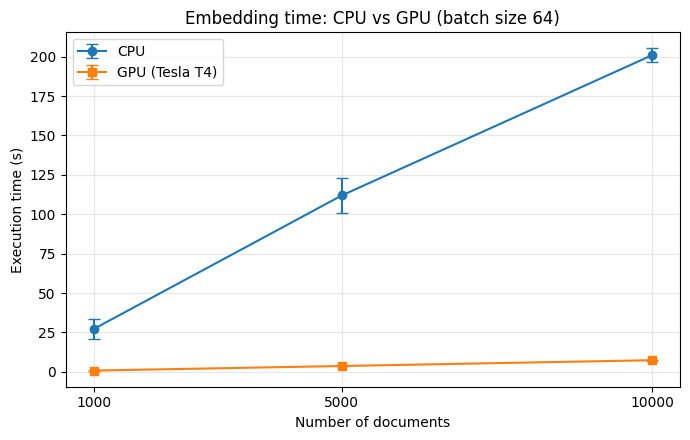

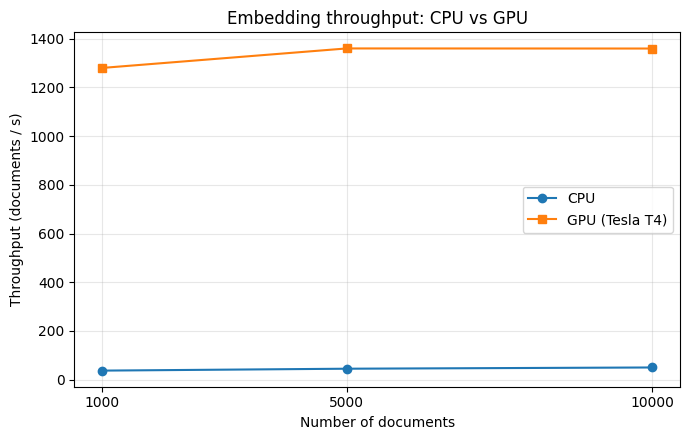

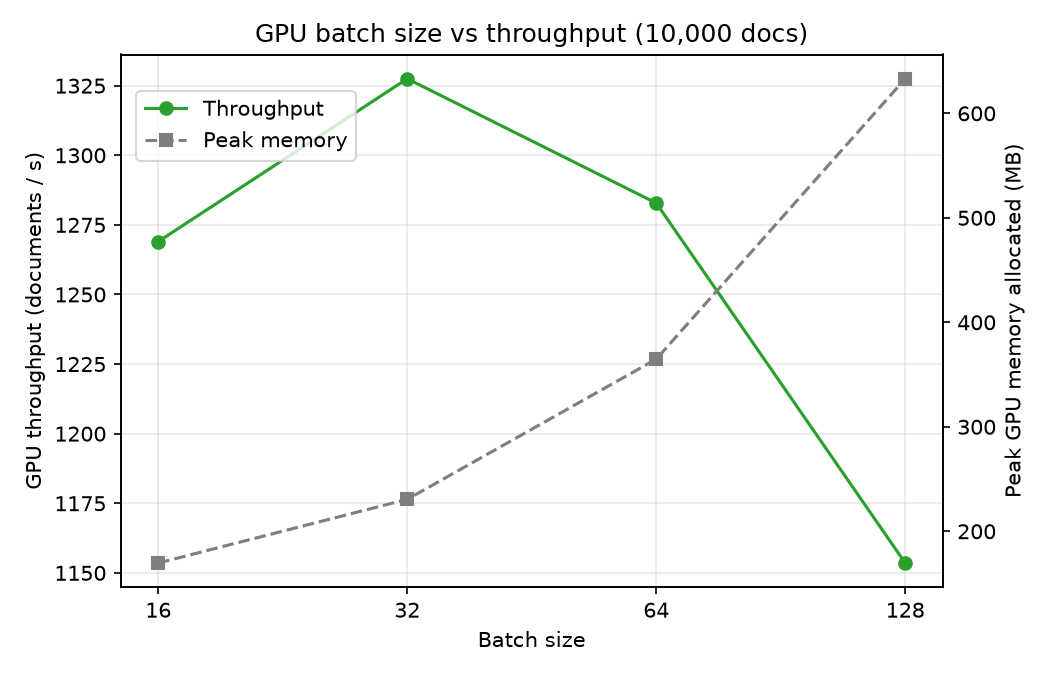

In [14]:
sizes = comparison.index.to_list()

# 1. Dataset size vs execution time
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(sizes, cpu_df["mean_time_s"], yerr=cpu_df["std_time_s"], marker="o", capsize=4, label="CPU")
ax.errorbar(sizes, gpu_df["mean_time_s"], yerr=gpu_df["std_time_s"], marker="s", capsize=4, label=f"GPU ({env['gpu_name']})")
ax.set(xlabel="Number of documents", ylabel="Execution time (s)",
       title=f"Embedding time: CPU vs GPU (batch size {DEFAULT_BS})", xticks=sizes)
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig("plots/cpu_vs_gpu_time.png", dpi=150); plt.show()

# 2. Dataset size vs throughput
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, cpu_df["throughput_docs_per_s"], marker="o", label="CPU")
ax.plot(sizes, gpu_df["throughput_docs_per_s"], marker="s", label=f"GPU ({env['gpu_name']})")
ax.set(xlabel="Number of documents", ylabel="Throughput (documents / s)",
       title="Embedding throughput: CPU vs GPU", xticks=sizes)
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig("plots/cpu_vs_gpu_throughput.png", dpi=150); plt.show()

# 3. Batch size vs GPU throughput (with peak memory on a second axis)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(batch_df["batch_size"], batch_df["throughput_docs_per_s"], marker="o", color="tab:green", label="Throughput")
ax.set(xlabel="Batch size", ylabel="GPU throughput (documents / s)",
       title="GPU batch size vs throughput (10,000 docs)", xscale="log")
ax.set_xticks(BATCH_SIZES, labels=BATCH_SIZES); ax.minorticks_off()
ax2 = ax.twinx()
ax2.plot(batch_df["batch_size"], batch_df["peak_mem_allocated_mb"], marker="s", ls="--", color="tab:gray", label="Peak memory")
ax2.set_ylabel("Peak GPU memory allocated (MB)")
ax.grid(alpha=0.3)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
fig.tight_layout(); fig.savefig("plots/batch_size_throughput.png", dpi=150); plt.show()

#### Are CPU and GPU embeddings the same?

GPU kernels can add up floating-point numbers in a different order, so tiny differences around 1e-6 are expected.
This check compares the embeddings for the 1,000-document subset.

In [15]:
a, b = cpu_embeddings[1_000], gpu_embeddings[1_000]
abs_diff = np.abs(a - b)
cos = np.sum(a * b, axis=1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))

equiv = {
    "mean_abs_diff": float(abs_diff.mean()),
    "max_abs_diff": float(abs_diff.max()),
    "min_cosine_similarity": float(cos.min()),
    "mean_cosine_similarity": float(cos.mean()),
}
for k, v in equiv.items():
    print(f"{k:24s}: {v:.3e}" if "diff" in k else f"{k:24s}: {v:.8f}")
pd.Series(equiv).to_csv("results/cpu_gpu_equivalence.csv", header=["value"])

# Do both devices give the same nearest neighbours? (top-5 overlap for 50 docs)
def top5(E):
    idx = faiss.IndexFlatIP(E.shape[1]); En = E / np.linalg.norm(E, axis=1, keepdims=True)
    idx.add(En.astype("float32")); return idx.search(En[:50].astype("float32"), 5)[1]
overlap = np.mean([len(set(x) & set(y)) / 5 for x, y in zip(top5(a), top5(b))])
print(f"Top-5 neighbour overlap CPU vs GPU: {overlap:.1%}")

mean_abs_diff           : 2.995e-08
max_abs_diff            : 2.161e-07
min_cosine_similarity   : 0.99999988
mean_cosine_similarity  : 1.00000000
Top-5 neighbour overlap CPU vs GPU: 100.0%


#### Experiment 4: Semantic search with FAISS

The search index is built on the GPU embeddings of the 10,000 documents.
The embeddings are **L2-normalized**, so ranking by L2 distance in `IndexFlatL2` gives the same order as ranking by cosine similarity, which is the metric MiniLM was trained for.
`IndexFlatL2` is an *exact* (brute-force) index, which is fast enough for 10k vectors.

In [16]:
doc_texts = subsets[10_000]
doc_embeddings = gpu_model.encode(doc_texts, batch_size=DEFAULT_BS, normalize_embeddings=True,
                                  convert_to_numpy=True, show_progress_bar=False).astype("float32")

dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)
print("dimension:", dimension, "| vectors in index:", index.ntotal)

dimension: 384 | vectors in index: 10000


In [17]:
categories = df["category"].tolist()

def search(query, k=5, show=True):
    torch.cuda.synchronize(); t0 = time.perf_counter()
    q = gpu_model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    torch.cuda.synchronize(); t1 = time.perf_counter()
    distances, indices = index.search(q, k)
    t2 = time.perf_counter()
    if show:
        print(f"\nQuery: {query}")
        print(f"(query embedding {1000*(t1-t0):.1f} ms, FAISS search {1000*(t2-t1):.2f} ms)")
        for rank, (d, i) in enumerate(zip(distances[0], indices[0]), 1):
            cos_sim = 1 - d / 2   # for unit vectors: ||a-b||^2 = 2 - 2cos
            print(f"  {rank}. [{categories[i]:8s} | cos={cos_sim:.3f}] {doc_texts[i][:160]}")
    return [{"query": query, "rank": r, "doc_id": int(i), "category": categories[i],
             "cosine_similarity": float(1 - d / 2), "text": doc_texts[i]}
            for r, (d, i) in enumerate(zip(distances[0], indices[0]), 1)]

Example queries are phrased *differently* from news headlines on purpose. If a result is relevant even though it doesn't share the query's keywords, that shows semantic matching at work.

In [18]:
queries = [
    "Oil prices going up because of supply problems",
    "A football team won the championship final",
    "New smartphone released by a tech company",
    "Elections and voting results in a foreign country",
    "Scientists discover something about space and planets",
    "Company profits fall and shares drop",
    "Computer virus attacks and online security threats",
    "Peace talks between countries in conflict",
]
search_rows = []
for q in queries:
    search_rows += search(q)
pd.DataFrame(search_rows).to_csv("results/search_examples.csv", index=False)


Query: Oil prices going up because of supply problems
(query embedding 93.5 ms, FAISS search 1.40 ms)
  1. [Sci/Tech | cos=0.725] High Oil Prices Might Be A Blessing In Disguise The absolute price of oil has reached a new high. The growth     of the economies in China, India and the rest o
  2. [Business | cos=0.680] Tight US supplies boost oil price Oil prices have surged to two-week highs following news that supplies in the US are tightening. In New York on Thursday, the c
  3. [Business | cos=0.636] Oil Holds Above \$46 Supply Worries Linger  LONDON (Reuters) - Oil prices held firm on Tuesday as China  showed no let-up in its strong import growth and U.S. G
  4. [Business | cos=0.625] Prices of oil drop despite sabotage Oil futures dropped by nearly \$1 per barrel yesterday despite more sabotage of Iraqi oil infrastructure, reinforcing the vi
  5. [Business | cos=0.622] Oil Hits \$47 as Supply Worries Linger  LONDON (Reuters) - Oil prices hit a one month-high of \$47 a  barrel on T

### Try your own query

In [19]:
_ = search("How are athletes preparing for the Olympics?")


Query: How are athletes preparing for the Olympics?
(query embedding 11.2 ms, FAISS search 1.06 ms)
  1. [Sci/Tech | cos=0.529] Nature and Nurture, the Recipe for Olympic Gold Olympic champions have their parents to thank for their physiology #151;but no one is born a world-record holder
  2. [Sports   | cos=0.486] Another medal, two records ATHENS -- Attention, ladies and gentlemen. For his next act, Michael Phelps will break an Olympic record, hurry to the warm-down pool
  3. [Sports   | cos=0.484] Athens Olympics Games: Expensive and Over-Hyped Olympics? JEDDAH, 20 August 2004  First, let me make it clear that I have always enjoyed watching the Olympic Ga
  4. [World    | cos=0.473] Phelps to Forgo Final Race of Olympics ATHENS, Greece - Michael Phelps is done for the Olympics. Shortly after winning his fifth gold medal and seventh overall,
  5. [Sports   | cos=0.465] IOC Still Concerned About Turin Housing (AP) AP - The IOC expressed renewed concern Wednesday about housing at the 

### Semantic search vs keyword search

This cell compares the semantic results with a naive keyword baseline that ranks documents by how many query words they contain.

In [20]:
STOP = {"a","an","the","of","in","on","for","to","and","by","about","is","are","with","because","something","between"}

def keyword_search(query, k=5):
    q_words = {w for w in query.lower().split() if w not in STOP}
    scores = [len(q_words & set(t.lower().split())) for t in doc_texts]
    top = np.argsort(scores)[::-1][:k]
    return [(scores[i], doc_texts[i]) for i in top]

q = "Oil prices going up because of supply problems"
print("KEYWORD top-5:")
for s, t in keyword_search(q):
    print(f"  [{s} words matched] {t[:140]}")
_ = search(q)

KEYWORD top-5:
  [4 words matched] Blue Chips Drop, Oil Reaches \$49 a Barrel  NEW YORK (Reuters) - U.S. blue-chip stocks fell  on  Thursday and crude oil prices touched \$49 
  [3 words matched] Oil Down Again; U.S. Crude Stocks Seen Up (Reuters) Reuters - Oil prices tiptoed lower on Tuesday,\marking a fourth day of losses as worries
  [3 words matched] Iraq supply helps steady oil price SINGAPORE -- The restoring of oil exports from Iraq helped keep prices steady in Asia Tuesday but concern
  [3 words matched] Stocks Are Up Despite Rising Oil Prices NEW YORK - Buyers put a positive spin on equities Wednesday, shrugging off rising crude futures as G
  [3 words matched] Oil Up as Ivan Threatens US Facilities World oil prices climbed on Monday as companies operating in the US Gulf of Mexico braced for output 

Query: Oil prices going up because of supply problems
(query embedding 7.7 ms, FAISS search 1.36 ms)
  1. [Sci/Tech | cos=0.725] High Oil Prices Might Be A Blessing In Disguise Th

#### Results summary

Hardware: **Tesla T4** (15 GB) GPU vs Colab CPU with **1 PyTorch thread** (1 physical core). Model: all-MiniLM-L6-v2. All times are the mean of 3 runs after warm-up.

| Documents | CPU time (s) | GPU time (s) | CPU docs/s | GPU docs/s | Speedup |
|---:|---:|---:|---:|---:|---:|
| 1,000 | 27.13 | 0.78 | 37 | 1,280 | 34.7× |
| 5,000 | 111.91 | 3.68 | 45 | 1,360 | 30.4× |
| 10,000 | 200.92 | 7.35 | 50 | 1,360 | 27.3× |

| Batch size | GPU time (s) | GPU docs/s | Peak allocated (MB) |
|---:|---:|---:|---:|
| 16 | 7.88 | 1,269 | 170 |
| 32 | 7.53 | 1,327 | 231 |
| 64 | 7.80 | 1,283 | 365 |
| 128 | 8.67 | 1,154 | 633 |

**Findings**
- **The GPU was 27–35× faster** than the single-core CPU at every dataset size.
- **Speedup fell slightly as the dataset grew.** The T4 was already near its maximum throughput at 1,000 docs (1,280 vs 1,360 docs/s), because a small model like MiniLM keeps the GPU busy even at that size. CPU throughput rose with size (37 → 50 docs/s), partly because its first 1k run was unusually slow (36 s vs about 22 s for the next two runs).
- **Larger batches did not help beyond 32.** Batch sizes 16–64 are within about 5% of each other, and batch 128 was about 13% slower than 32 while using 2.7× the memory. Likely causes are CPU-side tokenization on one core and extra padding in large batches.
- **Memory cost is small.** Peak memory was 633 MB at batch 128, out of 15 GB. About 87 MB of that is the model weights. `nvidia-smi` reported 1,177 MB because it also counts the caching allocator and the CUDA context.
- **CPU and GPU embeddings are numerically equivalent.** The mean absolute difference was 3.0×10⁻⁸, the minimum cosine similarity was 0.9999999, and the top-5 neighbours overlapped 100%.
- **Semantic search worked.** All 8 example queries returned relevant passages. After the first query (94 ms, one-time warm-up), each query embedding took about 6–11 ms, and FAISS search over 10k vectors took about 1 ms.

**Limitation:** the CPU baseline is a single core. A multi-core CPU would reduce the speedup, so these figures compare a T4 with one CPU core, not with a typical modern CPU.


In [21]:
# Print the key numbers in one place for the write-up
print(env["gpu_name"], "| CPU threads:", env["cpu_threads"])
print(comparison.round(3).to_string())
print()
print(batch_df.round(2).to_string(index=False))
print()
print({k: f"{v:.3e}" for k, v in equiv.items()})

Tesla T4 | CPU threads: 1
           CPU time (s)  GPU time (s)  CPU throughput (docs/s)  GPU throughput (docs/s)  Speedup (CPU/GPU)  GPU peak mem (MB)
Documents                                                                                                                    
1000             27.125         0.781                   36.866                 1280.286             34.728            364.777
5000            111.909         3.675                   44.679                 1360.402             30.448            364.777
10000           200.921         7.353                   49.771                 1360.029             27.326            364.777

 batch_size  mean_time_s  std_time_s  throughput_docs_per_s  peak_mem_allocated_mb  peak_mem_reserved_mb
         16         7.88        0.14                1269.00                 169.61                 230.0
         32         7.53        0.22                1327.50                 230.59                 342.0
         64         7.80    